# Вариант 16. Задача 2. Линейное программирование
## Постановка задачи
В пункте В2 сталь поступает на условный производственный комплекс, состоящий из сталелитейного и станкостроительного заводов. Он функционирует в течение 5 лет.

Начальный запас стали составляет 6700 т (для решения; интервал для исследования — 1000–10000 т (*)).
Исходные производственные мощности заводов соответственно:
- по стали — 3200 т в год;
- по станкам — 1600 станков в год (для решения; интервал для исследования — 100–5000 станков). (**)

Сталь расходуется на производство станков (1.2 т на каждый) и собственно стали, а также на расширение производственных мощностей комплекса. При этом каждая тонна стали, направленная на ее производство обеспечивает выпуск 3.0 т. Тонна стали, идущая на расширение производственной мощности сталелитейного завода, увеличивает последнюю на 0.3 т, а для увеличения производственных мощностей станкостроительного завода на один станок необходимо затратить 15 т стали.
Реализация решения о распределении стали на следующий год осуществляется в конце очередного года планируемого периода; станкостроительный завод не может получать более половины имеющегося запаса стали.

Требуется:
1. определить план распределения стали между сталелитейным и станкостроительным заводами, обеспечивающий выпуск максимального количества станков за плановый период;
2. провести исследование (поочередно, по одному фактору) влияния начальных условий (*) и (**) на структуру и результат решения (т.е. на распределение стали и на объем выпуска станков).


## Формализация задачи

Пусть $t \in \{1, \dots, 5\}$.

Переменные:
- $x_{1,t} (т)$ — расход на выплавку стали в году $t$
- $x_{2,t} (т)$ — расход на производство станков в году $t$
- $x_{3,t} (т)$ — расход на расширение сталелитейных мощностей в году $t$
- $x_{4,t} (т)$ — расход на расширение станкостроительных мощностей в году $t$

- $S_t (т)$ — запас стали на начало года $t$
- $P_{S, t} (т/год)$ — производственная мощность сталелитейного завода в году $t$
- $P_{M, t} (станков/год)$ — производственная мощность станкостроительного завода в году $t$

- $S_{start} = 6700 (т)$ — начальный запас стали
- $P_{S, start} = 3200 (т/год)$ — начальная мощность сталелитейного завода
- $P_{M, start} = 1600 (станков/год)$ — начальная мощность станкостроительного завода
- $k_s = 3.0$ — коэффициент выпуска стали из сырья
- $c_m = 1.2 (т/шт.)$ — удельный расход стали на один станок
- $\alpha = 0.3$ — прирост мощности стали на 1 $т$ затраченной стали
- $\beta = 15.0$ — затраты стали на увеличение мощности станков на 1 $ед$
- $y_t$ - число произведённых станков в году $t$

$x_{2,t} = c_m \cdot y_t$

Целевая функция:

$\sum_{t=1}^{5} y_t \rightarrow max$


Начальные условия ($t=1$):

$S_1 = 6700 т, \quad P_{S,1} = 3200, \quad P_{M,1} = 1600$


Система ограничений для каждого года $t$:
1. Баланс запасов: $x_{1,t} + x_{2,t} + x_{3,t} + x_{4,t} \leq S_t$
2. Мощность сталелитейная: $k_s \cdot x_{1,t} \leq P_{S,t}$
3. Мощность станкостроительная: $\frac{x_{2,t}}{c_m} \leq P_{M,t}$
4. Лимит распределения: $x_{2,t} \leq 0.5 \cdot S_t$
5. Расход стали: $x_{i,t} \geq 0$


Уравнения динамики (переход к году $t+1$):

$S_{t+1} = S_t - \sum_{i=1}^{4} x_{i,t} + k_s \cdot x_{1,t}$

$P_{S,t+1} = P_{S,t} + \alpha \cdot x_{3,t}$

$P_{M,t+1} = P_{M,t} + \frac{x_{4,t}}{\beta}$

## Описание задачи с помощью средств библиотеки PuLP

In [21]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
def run_production_model(s_start, pm_start, t_periods=5):
    prob = pulp.LpProblem("Production_Optimization", pulp.LpMaximize)

    # Константы
    ks, cm, alpha, beta = 3.0, 1.2, 0.3, 15.0
    ps_start = 3200
    years = range(1, t_periods + 1)

    # Переменные
    x1 = pulp.LpVariable.dicts("steel_prod", years, lowBound=0)
    x2 = pulp.LpVariable.dicts("machine_prod", years, lowBound=0)
    x3 = pulp.LpVariable.dicts("expand_steel", years, lowBound=0)
    x4 = pulp.LpVariable.dicts("expand_machines", years, lowBound=0)

    # Состояния
    S, PS, PM = {1: s_start}, {1: ps_start}, {1: pm_start}

    # Целевая функция
    prob += pulp.lpSum([x2[t] / cm for t in years])

    for t in years:
        # Ограничения года t
        prob += x1[t] + x2[t] + x3[t] + x4[t] <= S[t], f"Steel_Balance_{t}"
        prob += ks * x1[t] <= PS[t], f"Steel_Cap_{t}"
        prob += x2[t] / cm <= PM[t], f"Machine_Cap_{t}"
        prob += x2[t] <= 0.5 * S[t], f"Limit_50_pct_{t}"

        # Динамика на t+1
        if t < t_periods:
            S[t+1] = S[t] + (ks - 1)*x1[t] - x2[t] - x3[t] - x4[t]
            PS[t+1] = PS[t] + alpha * x3[t]
            PM[t+1] = PM[t] + x4[t] / beta

    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    # Сбор детального плана
    plan_data = []
    for t in years:
        plan_data.append({
            "Год": t,
            "Запас стали (S)": pulp.value(S[t]),
            "На сталь (x1)": pulp.value(x1[t]),
            "На станки (x2)": pulp.value(x2[t]),
            "Расш. стали (x3)": pulp.value(x3[t]),
            "Расш. станков (x4)": pulp.value(x4[t]),
            "Мощность станков (PM)": pulp.value(PM[t]),
            "Выпуск (шт)": pulp.value(x2[t] / cm)
        })

    return pulp.value(prob.objective), pd.DataFrame(plan_data)

## Решение задачи. Интерпретация решения в терминах постановки задачи.

In [23]:
total_value, df_plan = run_production_model(6700, 1600)
print(f"Максимальный выпуск: {total_value:.2f}")
display(df_plan)

Максимальный выпуск: 8706.97


,Год,Запас стали (S),На сталь (x1),На станки (x2),Расш. стали (x3),Расш. станков (x4),Мощность станков (PM),Выпуск (шт)
0,1,6700.000000,1066.6667,1920.0000,0.0,2649.425300,1600.000000,1600.000000
1,2,4263.908100,1066.6667,2131.9540,0.0,1.189061,1776.628353,1776.628333
2,3,4264.098439,1066.6667,2132.0491,0.0,1.107057,1776.707624,1776.707583
3,4,4264.275683,1066.6667,2132.1377,0.0,1.030708,1776.781428,1776.781417
4,5,4264.440675,0.0000,2132.2202,0.0,0.000000,1776.850142,1776.850167


## Исследование решения для ответа на вопросы, указанные в варианте задания.

In [24]:
# 1. Исследование влияния начального запаса стали (*)
s_test_values = [1000, 3000, 5000, 6700, 8000, 10000]
s_results = []

for s in s_test_values:
    # Используем новую универсальную функцию.
    # Так как план (DataFrame) нам здесь не нужен, записываем его в заглушку '_'
    obj, _ = run_production_model(s_start=s, pm_start=1600)
    s_results.append({"Начальный запас (S*)": s, "Общий выпуск станков": obj})

df_s = pd.DataFrame(s_results)

# 2. Исследование влияния начальной мощности станков (PM**)
pm_test_values = [100, 500, 1000, 1600, 3000, 5000]
pm_results = []

for pm in pm_test_values:
    obj, _ = run_production_model(s_start=6700, pm_start=pm)
    pm_results.append({"Начальная мощность (PM**)": pm, "Общий выпуск станков": obj})

df_pm = pd.DataFrame(pm_results)

# Вывод результатов
print("Влияние запаса стали (*):")
display(df_s)

print("\nВлияние мощности по станкам (**):")
display(df_pm)

Влияние запаса стали (*):


,Начальный запас (S*),Общий выпуск станков
0,1000,5988.357167
1,3000,7617.512583
2,5000,8354.764250
3,6700,8706.967500
4,8000,8954.920667
5,10000,9335.873000



Влияние мощности по станкам (**):


,Начальная мощность (PM**),Общий выпуск станков
0,100,2595.412967
1,500,4285.496167
2,1000,6387.325250
3,1600,8706.967500
4,3000,10853.298667
5,5000,10853.298667


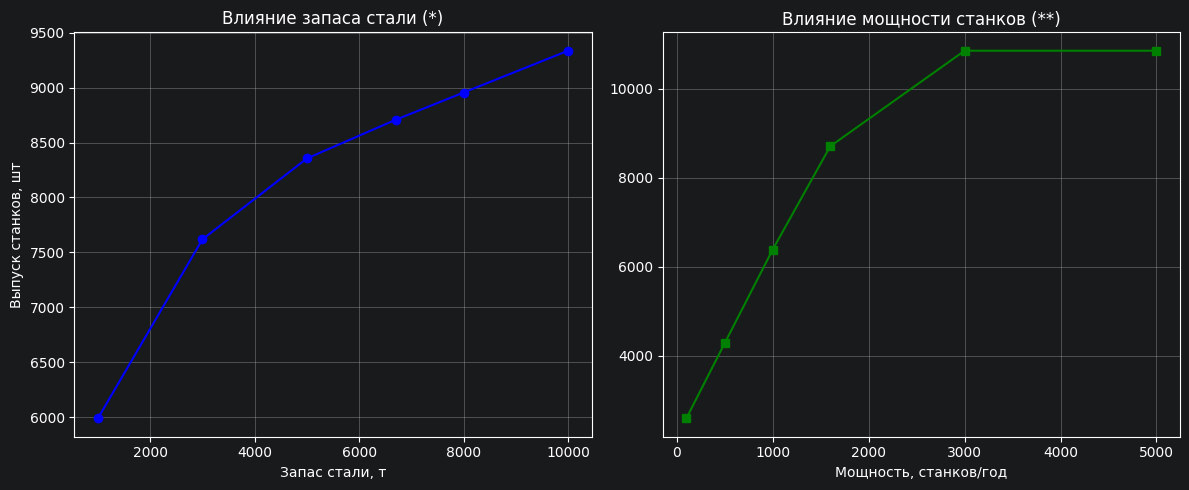

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_s["Начальный запас (S*)"], df_s["Общий выпуск станков"], marker='o', color='blue')
plt.title("Влияние запаса стали (*)")
plt.xlabel("Запас стали, т")
plt.ylabel("Выпуск станков, шт")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(df_pm["Начальная мощность (PM**)"], df_pm["Общий выпуск станков"], marker='s', color='green')
plt.title("Влияние мощности станков (**)")
plt.xlabel("Мощность, станков/год")
plt.grid(True)

plt.tight_layout()
plt.show()